In [1]:
import torch
import matplotlib.pyplot as plt
from torch import nn
import torchvision
from torchvision import transforms
import pandas as pd


In [2]:
import kagglehub
import os

# Download latest version
path = kagglehub.dataset_download("prahladmehandiratta/cervical-cancer-largest-dataset-sipakmed")
print("Path to dataset files:", path)

100%|██████████| 6.40G/6.40G [03:45<00:00, 30.5MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/prahladmehandiratta/cervical-cancer-largest-dataset-sipakmed/versions/1


In [3]:
classes = os.listdir(path)
print("Classes:", classes)
for cls in classes:
    cls_path = os.path.join(path, cls)
    n_images = len(os.listdir(cls_path))
    print(f"{cls}: {n_images} images")

Classes: ['im_Koilocytotic', 'im_Parabasal', 'im_Dyskeratotic', 'im_Superficial-Intermediate', 'im_Metaplastic']
im_Koilocytotic: 1 images
im_Parabasal: 1 images
im_Dyskeratotic: 1 images
im_Superficial-Intermediate: 1 images
im_Metaplastic: 1 images


In [4]:
IMG_SIZE = 224

train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(15),
    transforms.ColorJitter(0.2,0.2,0.2),
    transforms.RandomAffine(0, shear=10, scale=(0.8, 1.2)),
    transforms.ToTensor()
]
)

val_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor()
    ])

In [5]:
from torch.utils.data import Dataset
from PIL import Image
import os

class SipakMedDataset(Dataset):
    def __init__(self, root_dir, transform=None, valid_ext=(".png", ".bmp", ".jpg", ".jpeg")):
        self.samples = []
        self.transform = transform
        self.classes = sorted(os.listdir(root_dir))

        for cls_idx, cls in enumerate(self.classes):
            cls_path = os.path.join(root_dir, cls, cls)
            for f in os.listdir(cls_path):
                if f.lower().endswith(valid_ext):
                    self.samples.append((os.path.join(cls_path, f), cls_idx))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        img_path, label = self.samples[idx]
        image = Image.open(img_path).convert("RGB")  # use PIL for transforms
        if self.transform:
            image = self.transform(image)
        return image, label


In [6]:
from torch.utils.data import DataLoader, random_split

dataset_path = "/kaggle/input/cervical-cancer-largest-dataset-sipakmed"

# Full dataset with augmentations
full_dataset = SipakMedDataset(root_dir=path, transform=train_transform)

# Train/val split (80-20)
train_size = int(0.8 * len(full_dataset))
val_size = len(full_dataset) - train_size
train_dataset, val_dataset = random_split(full_dataset, [train_size, val_size])


In [7]:
train_loader = DataLoader(train_dataset, batch_size= 32, shuffle= True)
test_loader = DataLoader(val_dataset, batch_size = 32, shuffle=False)

print(f"Train samples: {len(train_dataset)}, Val samples: {len(val_dataset)}")

Train samples: 772, Val samples: 194


(np.float64(-0.5), np.float64(223.5), np.float64(223.5), np.float64(-0.5))

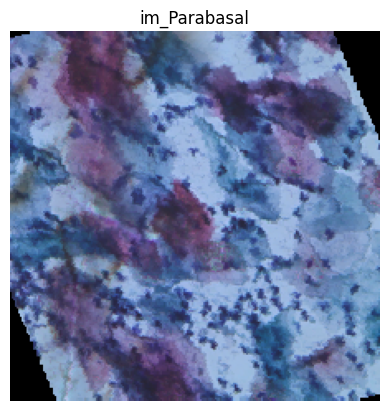

In [8]:
image_batch, label_batch = next(iter(train_loader))

image, label = image_batch[3], label_batch[3]

image.shape, label

plt.imshow(image.permute(1,2,0))
plt.title(classes[label])
plt.axis(False)

Number of patches per row: 14.0
Patch size: 16 pixels x 16 pixels


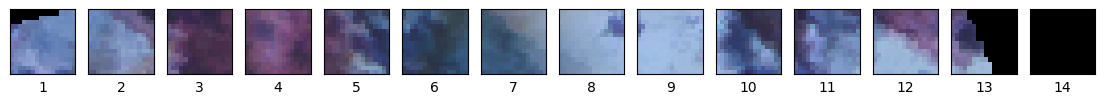

In [9]:
img_size = 224
patch_size= 16

num_patches = img_size/patch_size

image_permuted = image.permute(1, 2, 0)
assert img_size % patch_size ==0
print(f"Number of patches per row: {num_patches}\nPatch size: {patch_size} pixels x {patch_size} pixels")

fig, axs = plt.subplots(
    nrows =1,
    ncols= img_size// patch_size,
    figsize =(num_patches, num_patches),
    sharex= True,
    sharey = True
)

for i, patch in enumerate(range(0, img_size, patch_size)):
    axs[i].imshow(image_permuted[:patch_size, patch:patch+patch_size, :]); # keep height index constant, alter the width index
    axs[i].set_xlabel(i+1) # set the label
    axs[i].set_xticks([])
    axs[i].set_yticks([])

In [10]:
class PatchEmbedding(nn.Module):
  def __init__(self,
               in_channels=3,
               patch_size= 16,
               embedding_dim= 786):
    super().__init__()
    # turn and image into pathches
    self.patcher = nn.Conv2d(in_channels=in_channels,
                             out_channels=embedding_dim,
                             kernel_size=patch_size,
                             stride=patch_size,
                             padding=0)
    self.flatten = nn.Flatten(start_dim=2, end_dim=3)

  def forward(self,x):
    image_resolution = x.shape[-1]

    x_patched = self.patcher(x)
    x_flattened = self.flatten(x_patched)
    return x_flattened.permute(0,2,1) #adjust so the embedding is on the final dimension [batch_size, P^2•C, N] -> [batch_size, N, P^2•C]


In [11]:
torch.manual_seed(42)

# test on single image
patchify= PatchEmbedding(in_channels=3, patch_size=16, embedding_dim= 768)

print(f"Input image shape: {image.unsqueeze(0).shape}")
patch_embedded_image = patchify(image.unsqueeze(0))
print(f"Output patch emdedding shape: {patch_embedded_image.shape}")

Input image shape: torch.Size([1, 3, 224, 224])
Output patch emdedding shape: torch.Size([1, 196, 768])


In [12]:
# test
batch_size = patch_embedded_image.shape[0]
embedding_dimension = patch_embedded_image.shape[-1]

class_token = nn.Parameter(
    torch.ones(batch_size, 1, embedding_dimension),
    requires_grad=True
)

print(class_token[:,:,:10])
print(f"Class token shape: {class_token.shape} -> [batch_size, number_of_tokens, embedding_dimension]")

tensor([[[1., 1., 1., 1., 1., 1., 1., 1., 1., 1.]]], grad_fn=<SliceBackward0>)
Class token shape: torch.Size([1, 1, 768]) -> [batch_size, number_of_tokens, embedding_dimension]


In [13]:
# Add the class token embedding to the front of the patch embedding
patch_embedded_image_with_class_embedding = torch.cat((class_token, patch_embedded_image),
                                                      dim=1) # concat on first dimension

# Print the sequence of patch embeddings with the prepended class token embedding
print(patch_embedded_image_with_class_embedding)
print(f"Sequence of patch embeddings with class token prepended shape: {patch_embedded_image_with_class_embedding.shape} -> [batch_size, number_of_patches, embedding_dimension]")

tensor([[[ 1.0000,  1.0000,  1.0000,  ...,  1.0000,  1.0000,  1.0000],
         [-0.6082,  0.3192, -0.2061,  ...,  0.3920, -0.1431,  0.0772],
         [-0.5043,  0.0140, -0.2050,  ...,  0.4637, -0.1942,  0.1526],
         ...,
         [-0.3230,  0.2395, -0.1556,  ...,  0.2952, -0.1951,  0.1133],
         [-0.4634,  0.2709, -0.2683,  ...,  0.4526, -0.2073,  0.1232],
         [-0.5539,  0.0335,  0.0688,  ...,  0.3838, -0.3252,  0.0753]]],
       grad_fn=<CatBackward0>)
Sequence of patch embeddings with class token prepended shape: torch.Size([1, 197, 768]) -> [batch_size, number_of_patches, embedding_dimension]


In [14]:
# test
height, width = 224,224
number_of_patches = int((height*width)/patch_size**2)
embedding_dimension = patch_embedded_image_with_class_embedding.shape[2]


position_embedding = nn.Parameter(torch.ones(1,
                                             number_of_patches+1,
                                             embedding_dimension),
                                  requires_grad=True)
print(position_embedding[:, :10, :10])
print(f"Position embedding shape: {position_embedding.shape} -> [batch_size, number_of_patches, embedding_dimension]")


tensor([[[1., 1., 1., 1., 1., 1., 1., 1., 1., 1.],
         [1., 1., 1., 1., 1., 1., 1., 1., 1., 1.],
         [1., 1., 1., 1., 1., 1., 1., 1., 1., 1.],
         [1., 1., 1., 1., 1., 1., 1., 1., 1., 1.],
         [1., 1., 1., 1., 1., 1., 1., 1., 1., 1.],
         [1., 1., 1., 1., 1., 1., 1., 1., 1., 1.],
         [1., 1., 1., 1., 1., 1., 1., 1., 1., 1.],
         [1., 1., 1., 1., 1., 1., 1., 1., 1., 1.],
         [1., 1., 1., 1., 1., 1., 1., 1., 1., 1.],
         [1., 1., 1., 1., 1., 1., 1., 1., 1., 1.]]], grad_fn=<SliceBackward0>)
Position embedding shape: torch.Size([1, 197, 768]) -> [batch_size, number_of_patches, embedding_dimension]


In [15]:
# image embeddings

torch.manual_seed(42)
patch_size = 16
print(f"Image tensor shape: {image.shape}")
height, width = image.shape[1], image.shape[2]

x= image.unsqueeze(0)
print(f"Input image with batch dim shape: {x.shape}")

# image patch embedding
patch_embedding_layer= PatchEmbedding(in_channels=3,
                                     patch_size=patch_size,
                                     embedding_dim=768)

patch_embedding = patch_embedding_layer(x)
print(f"Patching embedding Shape: {patch_embedding.shape}")

batch_size = patch_embedding.shape[0]
embedding_dimension = patch_embedding.shape[-1]

# class token embedding
class_token = nn.Parameter(
    torch.ones(batch_size, 1, embedding_dimension),
    requires_grad=True
)
print(f"Class token embedding shape: {class_token.shape}")

patch_embedding_class_token = torch.cat((class_token, patch_embedding), dim=1)
print(f"Patch embedding with class token shape: {patch_embedding_class_token.shape}")


#  Create position embedding
number_of_patches = int((height * width) / patch_size**2)
position_embedding = nn.Parameter(torch.ones(1, number_of_patches+1, embedding_dimension),
                                  requires_grad=True)

# Add position embedding to patch embedding with class token
patch_and_position_embedding = patch_embedding_class_token + position_embedding
print(f"Patch and position embedding shape: {patch_and_position_embedding.shape}")



Image tensor shape: torch.Size([3, 224, 224])
Input image with batch dim shape: torch.Size([1, 3, 224, 224])
Patching embedding Shape: torch.Size([1, 196, 768])
Class token embedding shape: torch.Size([1, 1, 768])
Patch embedding with class token shape: torch.Size([1, 197, 768])
Patch and position embedding shape: torch.Size([1, 197, 768])


In [16]:
# transformer

class MultiheadSelfAttentionBlock(nn.Module):
  def __init__(self,
               embedding_dim = 768,
               num_heads=12,
               attn_dropout=0):
    super().__init__()

    self.layer_norm = nn.LayerNorm(normalized_shape=embedding_dim)
    self.multihead_attn = nn.MultiheadAttention(embed_dim=embedding_dim,
                                                num_heads=num_heads,
                                                dropout= attn_dropout,
                                                batch_first= True)
  def forward(self,x):
    x = self.layer_norm(x)
    attn_output, _ = self.multihead_attn(query=x,
                                         key=x,
                                         value=x,
                                         need_weights=False)
    return attn_output

In [17]:
# Create an instance of MSABlock
multihead_self_attention_block = MultiheadSelfAttentionBlock(embedding_dim=768, # from Table 1
                                                             num_heads=12) # from Table 1

# Pass patch and position image embedding through MSABlock
patched_image_through_msa_block = multihead_self_attention_block(patch_and_position_embedding)
print(f"Input shape of MSA block: {patch_and_position_embedding.shape}")
print(f"Output shape MSA block: {patched_image_through_msa_block.shape}")

Input shape of MSA block: torch.Size([1, 197, 768])
Output shape MSA block: torch.Size([1, 197, 768])


In [18]:
class MLPBlock(nn.Module):
  def __init__(self,
               embedding_dim = 768,
               mlp_size= 3072,
               dropout = 0.1):
    super().__init__()

    self.layer_norm = nn.LayerNorm(normalized_shape=embedding_dim)
    self.mlp = nn.Sequential(
        nn.Linear(in_features = embedding_dim,
                  out_features=mlp_size),
        nn.GELU(),
        nn.Dropout(p=dropout),
        nn.Linear(in_features=mlp_size,
                  out_features=embedding_dim),
        nn.Dropout(p=dropout)
    )
  def forward(self, x):
    x= self.layer_norm(x)
    x = self.mlp(x)
    return x


In [19]:
# Create an instance of MLPBlock
mlp_block = MLPBlock(embedding_dim=768, # from Table 1
                     mlp_size=3072, # from Table 1
                     dropout=0.1) # from Table 3

# Pass output of MSABlock through MLPBlock
patched_image_through_mlp_block = mlp_block(patched_image_through_msa_block)
print(f"Input shape of MLP block: {patched_image_through_msa_block.shape}")
print(f"Output shape MLP block: {patched_image_through_mlp_block.shape}")

Input shape of MLP block: torch.Size([1, 197, 768])
Output shape MLP block: torch.Size([1, 197, 768])


In [20]:
class TransformerEncoderBlock(nn.Module):
  def __init__(self,
               embedding_dim= 768,
               num_heads=12,
               mlp_size=3072,
               mlp_dropout=0.1,
               attn_dropout=0):
    super().__init__()
    self.msa_block = MultiheadSelfAttentionBlock(embedding_dim=embedding_dim,
                                                 num_heads=num_heads,
                                                 attn_dropout= attn_dropout)

    self.mlp_block = MLPBlock(embedding_dim=embedding_dim,
                              mlp_size= mlp_size,
                              dropout= mlp_dropout)

  def forward(self,x):
    x = self.msa_block(x)+x
    x = self.mlp_block(x) +x
    return x

In [21]:

transformer_encoder_block = TransformerEncoderBlock()

!pip install -q torchinfo
from torchinfo import summary
#summary of our Transformer Encoder
summary(model=transformer_encoder_block,
        input_size=(1, 197, 768), # (batch_size, num_patches, embedding_dimension)
        col_names=["input_size", "output_size", "num_params", "trainable"],
        col_width=20,
        row_settings=["var_names"])

Layer (type (var_name))                            Input Shape          Output Shape         Param #              Trainable
TransformerEncoderBlock (TransformerEncoderBlock)  [1, 197, 768]        [1, 197, 768]        --                   True
├─MultiheadSelfAttentionBlock (msa_block)          [1, 197, 768]        [1, 197, 768]        --                   True
│    └─LayerNorm (layer_norm)                      [1, 197, 768]        [1, 197, 768]        1,536                True
│    └─MultiheadAttention (multihead_attn)         --                   [1, 197, 768]        2,362,368            True
├─MLPBlock (mlp_block)                             [1, 197, 768]        [1, 197, 768]        --                   True
│    └─LayerNorm (layer_norm)                      [1, 197, 768]        [1, 197, 768]        1,536                True
│    └─Sequential (mlp)                            [1, 197, 768]        [1, 197, 768]        --                   True
│    │    └─Linear (0)                     

In [22]:
#ViT

class ViT(nn.Module):
  def __init__(self,
               img_size=224,
               in_channels = 3,
               patch_size= 16,
               num_transformer_layers = 12,
               embedding_dim = 768,
               mlp_size=3072,
               num_heads= 12,
               attn_dropout=0,
               mlp_dropout=0.1,
               embedding_dropout =0.1,
               num_classes=100):
    super().__init__()
    assert img_size % patch_size ==0

    self.num_patches = (img_size*img_size) // patch_size**2
    self.class_embedding = nn.Parameter(data= torch.randn(1,1,embedding_dim),
                                        requires_grad=True)
    self.position_embedding= nn.Parameter(data = torch.randn(1,self.num_patches+1, embedding_dim),
                                          requires_grad=True)

    self.embedding_dropout = nn.Dropout(p= embedding_dropout)

    self.patch_embedding = PatchEmbedding(in_channels = in_channels,
                                          patch_size = patch_size,
                                          embedding_dim= embedding_dim)

    self.transformer_encoder = nn.Sequential(*[TransformerEncoderBlock(
        embedding_dim = embedding_dim,
        num_heads=num_heads,
        mlp_size= mlp_size,
        mlp_dropout= mlp_dropout
    ) for _ in range(num_transformer_layers)])

    # classifier head
    self.classifier = nn.Sequential(
        nn.LayerNorm(normalized_shape=embedding_dim),
        nn.Linear(in_features=embedding_dim,
                  out_features = num_classes)
    )
  def forward(self, x):
    batch_size = x.shape[0]
    class_token = self.class_embedding.expand(batch_size,-1,-1)

    x = self.patch_embedding(x)
    x = torch.cat((class_token, x), dim=1)
    x = self.position_embedding + x

    x = self.embedding_dropout(x)
    x = self.transformer_encoder(x)

    x = self.classifier(x[:,0])

    return x

In [23]:
torch.manual_seed(42)

# test: creating the class embedding and expanding over a batch dimension
batch_size = 32
class_token_embedding_single = nn.Parameter(data=torch.randn(1, 1, 768)) # create a single learnable class token
class_token_embedding_expanded = class_token_embedding_single.expand(batch_size, -1, -1) # expand the single learnable class token across the batch dimension, "-1" means to "infer the dimension"

# Print out the change in shapes
print(f"Shape of class token embedding single: {class_token_embedding_single.shape}")
print(f"Shape of class token embedding expanded: {class_token_embedding_expanded.shape}")
random_image_tensor = torch.randn(1,3,224,224)

vit =ViT(num_classes = len(classes))
vit(random_image_tensor)

Shape of class token embedding single: torch.Size([1, 1, 768])
Shape of class token embedding expanded: torch.Size([32, 1, 768])


tensor([[ 0.5108,  1.6013,  0.4018, -0.1577, -0.5061]],
       grad_fn=<AddmmBackward0>)

In [24]:

# # Print a summary  ViT model
summary(model=vit,
        input_size=(32, 3, 224, 224), # (batch_size, color_channels, height, width)
        # col_names=["input_size"], # uncomment for smaller output
        col_names=["input_size", "output_size", "num_params", "trainable"],
        col_width=20,
        row_settings=["var_names"]
)

Layer (type (var_name))                                      Input Shape          Output Shape         Param #              Trainable
ViT (ViT)                                                    [32, 3, 224, 224]    [32, 5]              152,064              True
├─PatchEmbedding (patch_embedding)                           [32, 3, 224, 224]    [32, 196, 768]       --                   True
│    └─Conv2d (patcher)                                      [32, 3, 224, 224]    [32, 768, 14, 14]    590,592              True
│    └─Flatten (flatten)                                     [32, 768, 14, 14]    [32, 768, 196]       --                   --
├─Dropout (embedding_dropout)                                [32, 197, 768]       [32, 197, 768]       --                   --
├─Sequential (transformer_encoder)                           [32, 197, 768]       [32, 197, 768]       --                   True
│    └─TransformerEncoderBlock (0)                           [32, 197, 768]       [32, 197, 768]

In [25]:

from tqdm.auto import tqdm
from typing import Dict, List, Tuple

def train_step(model: torch.nn.Module,
               dataloader: torch.utils.data.DataLoader,
               loss_fn: torch.nn.Module,
               optimizer: torch.optim.Optimizer,
               device: torch.device) -> Tuple[float, float]:

    model.train()
    train_loss, train_acc = 0, 0
    for batch, (X, y) in enumerate(dataloader):

        X, y = X.to(device), y.to(device)

        # 1. Forward pass
        y_pred = model(X)

        # 2. Calculate  and accumulate loss
        loss = loss_fn(y_pred, y)
        train_loss += loss.item()

        # 3. Optimizer zero grad
        optimizer.zero_grad()

        # 4. Loss backward
        loss.backward()

        # 5. Optimizer step
        optimizer.step()

        # Calculate and accumulate accuracy metric across all batches
        y_pred_class = torch.argmax(torch.softmax(y_pred, dim=1), dim=1)
        train_acc += (y_pred_class == y).sum().item()/len(y_pred)

    # Adjust metrics to get average loss and accuracy per batch
    train_loss = train_loss / len(dataloader)
    train_acc = train_acc / len(dataloader)
    return train_loss, train_acc

def test_step(model: torch.nn.Module,
              dataloader: torch.utils.data.DataLoader,
              loss_fn: torch.nn.Module,
              device: torch.device) -> Tuple[float, float]:
    # Put model in eval mode
    model.eval()

    # Setup test loss and test accuracy values
    test_loss, test_acc = 0, 0

    # Turn on inference context manager
    with torch.inference_mode():
        # Loop through DataLoader batches
        for batch, (X, y) in enumerate(dataloader):
            # Send data to target device
            X, y = X.to(device), y.to(device)

            # 1. Forward pass
            test_pred_logits = model(X)

            # 2. Calculate and accumulate loss
            loss = loss_fn(test_pred_logits, y)
            test_loss += loss.item()

            # Calculate and accumulate accuracy
            test_pred_labels = test_pred_logits.argmax(dim=1)
            test_acc += ((test_pred_labels == y).sum().item()/len(test_pred_labels))

    # Adjust metrics to get average loss and accuracy per batch
    test_loss = test_loss / len(dataloader)
    test_acc = test_acc / len(dataloader)
    return test_loss, test_acc

def train(model: torch.nn.Module,
          train_dataloader: torch.utils.data.DataLoader,
          test_dataloader: torch.utils.data.DataLoader,
          optimizer: torch.optim.Optimizer,
          loss_fn: torch.nn.Module,
          epochs: int,
          device: torch.device) -> Dict[str, List]:
    # Create empty results dictionary
    results = {"train_loss": [],
               "train_acc": [],
               "test_loss": [],
               "test_acc": []
    }

    # Make sure model on target device
    model.to(device)

    # Loop through training and testing steps for a number of epochs
    for epoch in tqdm(range(epochs)):
        train_loss, train_acc = train_step(model=model,
                                          dataloader=train_dataloader,
                                          loss_fn=loss_fn,
                                          optimizer=optimizer,
                                          device=device)
        test_loss, test_acc = test_step(model=model,
          dataloader=test_dataloader,
          loss_fn=loss_fn,
          device=device)

        # Print out what's happening
        print(
          f"Epoch: {epoch+1} | "
          f"train_loss: {train_loss:.4f} | "
          f"train_acc: {train_acc:.4f} | "
          f"test_loss: {test_loss:.4f} | "
          f"test_acc: {test_acc:.4f}"
        )

        # Update results dictionary
        results["train_loss"].append(train_loss)
        results["train_acc"].append(train_acc)
        results["test_loss"].append(test_loss)
        results["test_acc"].append(test_acc)

    # Return the filled results at the end of the epochs
    return results

In [26]:
optimizer = torch.optim.Adam(params=vit.parameters(),
                             lr=3e-3,
                             betas=(0.9,0.999),
                             weight_decay= 0.3
)

loss_fn = torch.nn.CrossEntropyLoss()

device = "cuda" if torch.cuda.is_available() else "cpu"

torch.manual_seed(42)



In [27]:
results = train(model=vit,
                train_dataloader=train_loader,
                test_dataloader=test_loader,
                optimizer= optimizer,
                loss_fn = loss_fn,
                epochs= 10,
                device= device
                )

  0%|          | 0/10 [00:00<?, ?it/s]

KeyboardInterrupt: 

#Transfer learning

In [28]:
import torchvision
import torchvision.transforms as transforms
import torchvision.datasets as dset
import torchvision.models as models
# 1. Get pretrained weights for ViT-Base
pretrained_vit_weights = torchvision.models.ViT_B_16_Weights.DEFAULT # requires torchvision >= 0.13, "DEFAULT" means best available

# 2. Setup a ViT model instance with pretrained weights
pretrained_vit = torchvision.models.vit_b_16(weights=pretrained_vit_weights).to(device)

# 3. Freeze the base parameters
for parameter in pretrained_vit.parameters():
    parameter.requires_grad = False

# 4. Change the classifier head (set the seeds to ensure same initialization with linear head)
torch.manual_seed(42)
pretrained_vit.heads = nn.Linear(in_features=768, out_features=len(classes)).to(device)
# pretrained_vit # uncomment for model output
pretrained_vit_transforms = pretrained_vit_weights.transforms()
print(pretrained_vit_transforms)

Downloading: "https://download.pytorch.org/models/vit_b_16-c867db91.pth" to /root/.cache/torch/hub/checkpoints/vit_b_16-c867db91.pth


100%|██████████| 330M/330M [00:03<00:00, 110MB/s]


ImageClassification(
    crop_size=[224]
    resize_size=[256]
    mean=[0.485, 0.456, 0.406]
    std=[0.229, 0.224, 0.225]
    interpolation=InterpolationMode.BILINEAR
)


In [29]:

full_dataset = SipakMedDataset(root_dir=path, transform=pretrained_vit_transforms)
train_loader = DataLoader(train_dataset, batch_size= 32, shuffle= True)
test_loader = DataLoader(val_dataset, batch_size = 32, shuffle=False)

print(f"Train samples: {len(train_dataset)}, Val samples: {len(val_dataset)}")

Train samples: 772, Val samples: 194


In [34]:
optimizer = torch.optim.Adam(params=pretrained_vit.parameters(),
                             lr=1e-3)

In [35]:
results = train(model=pretrained_vit,
                train_dataloader=train_loader,
                test_dataloader=test_loader,
                optimizer= optimizer,
                loss_fn = loss_fn,
                epochs= 10,
                device= device
                )

  0%|          | 0/10 [00:00<?, ?it/s]

Epoch: 1 | train_loss: 1.2621 | train_acc: 0.5262 | test_loss: 1.0505 | test_acc: 0.6339
Epoch: 2 | train_loss: 0.8919 | train_acc: 0.7200 | test_loss: 0.9266 | test_acc: 0.6339
Epoch: 3 | train_loss: 0.7729 | train_acc: 0.7450 | test_loss: 0.7450 | test_acc: 0.7098
Epoch: 4 | train_loss: 0.6836 | train_acc: 0.7750 | test_loss: 0.7327 | test_acc: 0.7188
Epoch: 5 | train_loss: 0.6403 | train_acc: 0.7725 | test_loss: 0.6957 | test_acc: 0.7768
Epoch: 6 | train_loss: 0.5983 | train_acc: 0.8025 | test_loss: 0.6527 | test_acc: 0.7679
Epoch: 7 | train_loss: 0.5511 | train_acc: 0.8113 | test_loss: 0.6244 | test_acc: 0.8348
Epoch: 8 | train_loss: 0.5421 | train_acc: 0.8325 | test_loss: 0.5846 | test_acc: 0.8259
Epoch: 9 | train_loss: 0.5215 | train_acc: 0.8337 | test_loss: 0.6336 | test_acc: 0.7455
Epoch: 10 | train_loss: 0.5193 | train_acc: 0.8325 | test_loss: 0.6263 | test_acc: 0.7991


In [36]:
def plot_loss_curves(results):
    """Plots training curves of a results dictionary.

    Args:
        results (dict): dictionary containing list of values, e.g.
            {"train_loss": [...],
             "train_acc": [...],
             "test_loss": [...],
             "test_acc": [...]}
    """
    loss = results["train_loss"]
    test_loss = results["test_loss"]

    accuracy = results["train_acc"]
    test_accuracy = results["test_acc"]

    epochs = range(len(results["train_loss"]))

    plt.figure(figsize=(15, 7))

    # Plot loss
    plt.subplot(1, 2, 1)
    plt.plot(epochs, loss, label="train_loss")
    plt.plot(epochs, test_loss, label="test_loss")
    plt.title("Loss")
    plt.xlabel("Epochs")
    plt.legend()

    # Plot accuracy
    plt.subplot(1, 2, 2)
    plt.plot(epochs, accuracy, label="train_accuracy")
    plt.plot(epochs, test_accuracy, label="test_accuracy")
    plt.title("Accuracy")
    plt.xlabel("Epochs")
    plt.legend()


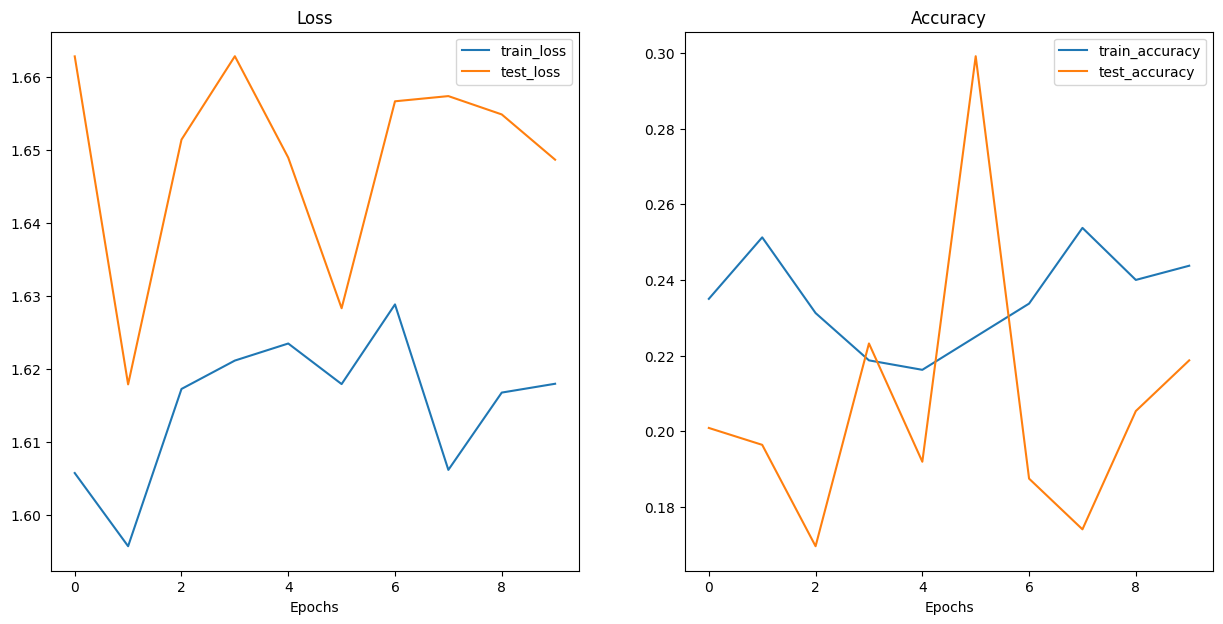

In [33]:
plot_loss_curves(results)

In [38]:
import torch
import matplotlib.pyplot as plt

def visualize_predictions(model, dataloader, classes, device, n=6):
    """
    Visualize model predictions on a batch from the test dataloader.
    Args:
        model: trained model (ViT)
        dataloader: test DataLoader
        classes: list of class names
        device: torch.device("cuda" or "cpu")
        n: number of images to visualize
    """
    model.eval()
    model.to(device)

    images_shown = 0

    with torch.inference_mode():
        for X, y in dataloader:
            X, y = X.to(device), y.to(device)
            preds = model(X)
            pred_classes = torch.argmax(preds, dim=1)

            plt.figure(figsize=(14, 8))
            for i in range(min(n, len(X))):
                ax = plt.subplot(2, n//2, i+1)
                img = X[i].permute(1, 2, 0).cpu().numpy()
                plt.imshow(img)
                plt.title(
                    f"Pred: {classes[pred_classes[i]]}\nTrue: {classes[y[i]]}",
                    color=("green" if pred_classes[i] == y[i] else "red")
                )
                plt.axis("off")
            plt.tight_layout()
            plt.show()

            # visualize only one batch
            break


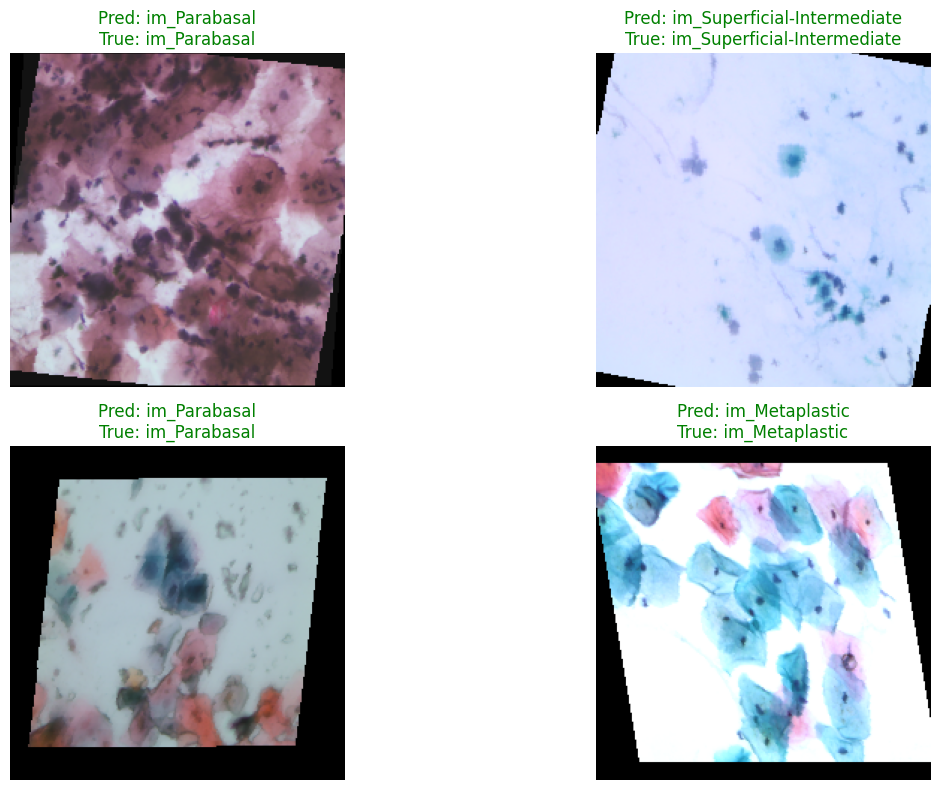

In [42]:
visualize_predictions(pretrained_vit, test_loader, classes=classes, device=device, n=4)